# Forecasting Models and Feature Experiments

This notebook compares history, calendar and weather features for day-ahead household forecasts.

## 1. Setup

The notebook shows the modeling logic directly. Reusable versions are saved in `src/`.

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

PROCESSED = ROOT / 'data/processed'
REPORTS = ROOT / 'reports'
FIGURES = REPORTS / 'figures'
OUTPUTS = ROOT / 'outputs'
MODELS = ROOT / 'models'
for folder in [FIGURES, OUTPUTS, MODELS]:
    folder.mkdir(parents=True, exist_ok=True)

TRAIN_START = pd.Timestamp('2012-09-01')
VALID_START = pd.Timestamp('2013-09-01')
TEST_START = pd.Timestamp('2013-11-01')
END = pd.Timestamp('2014-01-01')
SEED = 42

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:.4f}'.format

## 2. Training history

First, check if the selected households have one usable year before validation.

In [2]:
coverage = pd.read_csv(REPORTS / 'extended_training_coverage.csv')
display(coverage[['household_id', 'coverage', 'longest_missing_hours']].sort_values('coverage').head())
print('Households with at least 99% coverage:', (coverage['coverage'] >= .99).sum(), '/', len(coverage))
print('Median coverage:', round(coverage['coverage'].median(), 4))

,household_id,coverage,longest_missing_hours
8,MAC000310,0.9970,24.0000
14,MAC000523,0.9987,5.5000
13,MAC000521,0.9991,3.0000
22,MAC002078,0.9997,0.5000
17,MAC000688,0.9998,0.5000


Households with at least 99% coverage: 24 / 24
Median coverage: 0.9999


**Decision:** use September 2012 to August 2013 for training.

All 24 households have at least 99% coverage. The minimum is 99.70%, so the cohort follows the same rule as the exploration notebook.


## 3. Leakage-safe features

The forecast is made at midnight. All history features must come from earlier days.

In [3]:
panel = pd.read_parquet(PROCESSED / 'forecasting_panel.parquet')
keys = ['household_id', 'timestamp']

features = panel[keys + ['energy_kwh']].copy()
features['forecast_origin'] = features['timestamp'].dt.floor('D')
features['slot'] = features['timestamp'].dt.hour * 2 + features['timestamp'].dt.minute // 30
features['day_of_week'] = features['timestamp'].dt.dayofweek
features['weekend'] = (features['day_of_week'] >= 5).astype(int)
features['month'] = features['timestamp'].dt.month

for periods in [48, 336]:
    history = panel[keys + ['energy_kwh']].copy()
    history['timestamp'] = history['timestamp'] + pd.Timedelta(minutes=30 * periods)
    history = history.rename(columns={'energy_kwh': f'lag_{periods}'})
    features = features.merge(history, on=keys, how='left', validate='one_to_one')

Daily totals give the model the recent household level. Only complete earlier days are used.

In [4]:
daily = panel.assign(day=panel['timestamp'].dt.floor('D')).groupby(
    ['household_id', 'day']
)['energy_kwh'].agg(['count', 'sum']).reset_index()
daily['daily_total'] = daily['sum'].where(daily['count'] == 48)

for days, name in [(1, 'previous_day_total'), (7, 'previous_week_total')]:
    history = daily[['household_id', 'day', 'daily_total']].copy()
    history['forecast_origin'] = history['day'] + pd.Timedelta(days=days)
    history = history.rename(columns={'daily_total': name}).drop(columns='day')
    features = features.merge(
        history, on=['household_id', 'forecast_origin'], how='left', validate='many_to_one'
    )

features = features.loc[
    (features['forecast_origin'] >= TRAIN_START) & (features['forecast_origin'] < END)
].copy()

assert (features['timestamp'] - pd.Timedelta(days=1) < features['forecast_origin']).all()
assert (features['timestamp'] - pd.Timedelta(days=7) < features['forecast_origin']).all()
display(features.head())

,household_id,timestamp,energy_kwh,forecast_origin,slot,day_of_week,weekend,month,lag_48,lag_336,previous_day_total,previous_week_total
336,MAC000070,2012-09-01 00:00:00,0.0120,2012-09-01,0,5,1,9,0.0120,0.1080,4.5180,3.8670
337,MAC000070,2012-09-01 00:30:00,0.0400,2012-09-01,1,5,1,9,0.0440,0.0350,4.5180,3.8670
338,MAC000070,2012-09-01 01:00:00,0.0020,2012-09-01,2,5,1,9,0.0000,0.0160,4.5180,3.8670
339,MAC000070,2012-09-01 01:30:00,0.0040,2012-09-01,3,5,1,9,0.0020,0.0010,4.5180,3.8670
340,MAC000070,2012-09-01 02:00:00,0.0380,2012-09-01,4,5,1,9,0.0420,0.0470,4.5180,3.8670


## 4. Weather check

Observed target-day weather is not known at midnight. It is used only as an **oracle experiment**.

In [5]:
weather_raw = pd.read_csv(ROOT / 'archive/weather_hourly_darksky.csv', parse_dates=['time'])
weather_raw = weather_raw.sort_values('time')
weather_columns = ['temperature', 'humidity', 'windSpeed', 'pressure']

weather_check = pd.DataFrame({
    'missing': weather_raw[weather_columns].isna().sum(),
    'minimum': weather_raw[weather_columns].min(),
    'maximum': weather_raw[weather_columns].max(),
})
display(weather_check)

expected_hours = pd.date_range(weather_raw['time'].min(), weather_raw['time'].max(), freq='h')
print('Missing timestamps:', len(expected_hours.difference(weather_raw['time'])))
print('Duplicate timestamps:', weather_raw['time'].duplicated().sum())

,missing,minimum,maximum
temperature,0,-5.6400,32.4000
humidity,0,0.2300,1.0000
windSpeed,0,0.0400,14.8000
pressure,13,975.7400,1043.3200


Missing timestamps: 2
Duplicate timestamps: 0


The ranges are consistent with Celsius, humidity from 0 to 1, wind speed in m/s and pressure in hPa. The CSV has no unit metadata, so this remains an informed check.

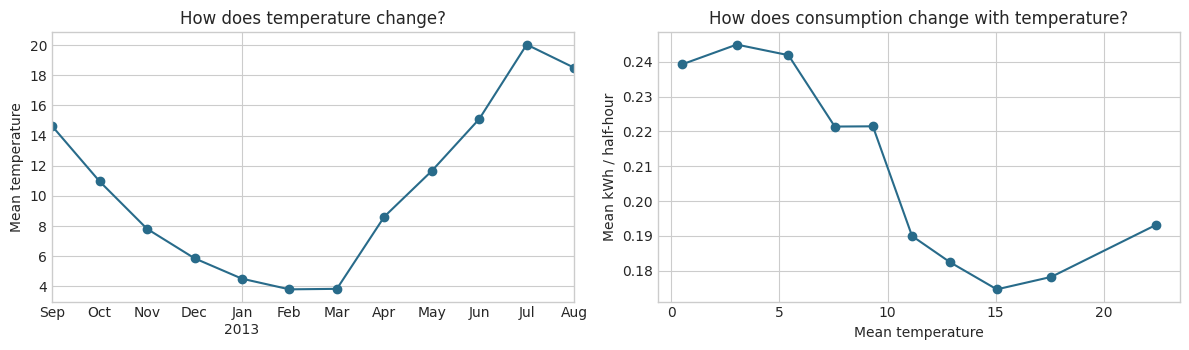

In [6]:
weather_train = weather_raw.loc[
    (weather_raw['time'] >= TRAIN_START) & (weather_raw['time'] < VALID_START)
].copy()
monthly_weather = weather_train.set_index('time')['temperature'].resample('MS').mean()

consumption_hour = panel.loc[
    (panel['timestamp'] >= TRAIN_START) & (panel['timestamp'] < VALID_START)
].assign(weather_hour=lambda x: x['timestamp'].dt.floor('h')).groupby('weather_hour')['energy_kwh'].mean()
weather_relation = weather_train.merge(
    consumption_hour.rename('mean_energy_kwh'), left_on='time', right_index=True, how='inner'
)
weather_relation['temperature_group'] = pd.qcut(
    weather_relation['temperature'], 10, duplicates='drop'
)
temperature_profile = weather_relation.groupby(
    'temperature_group', observed=True
).agg(temperature=('temperature', 'mean'), energy_kwh=('mean_energy_kwh', 'mean'))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
monthly_weather.plot(ax=axes[0], marker='o', color='#286b8a')
axes[0].set(title='How does temperature change?', xlabel='', ylabel='Mean temperature')
axes[1].plot(temperature_profile['temperature'], temperature_profile['energy_kwh'], marker='o', color='#286b8a')
axes[1].set(title='How does consumption change with temperature?', xlabel='Mean temperature', ylabel='Mean kWh / half-hour')
plt.tight_layout()
plt.savefig(FIGURES / 'forecasting_01_weather.png', dpi=140, bbox_inches='tight')
plt.show()

Consumption is higher at lower temperatures. Season and weather change together, so this plot does not prove a direct weather effect.

Fill the few hourly weather gaps by time interpolation. Each half-hour target receives the observation from its hour.

In [7]:
weather = weather_raw[['time'] + weather_columns].set_index('time').reindex(expected_hours)
weather[weather_columns] = weather[weather_columns].interpolate(method='time', limit_direction='both')
weather.index.name = 'weather_hour'
weather = weather.add_prefix('weather_').reset_index()

features['weather_hour'] = features['timestamp'].dt.floor('h')
features = features.merge(weather, on='weather_hour', how='left', validate='many_to_one')
assert features[[f'weather_{name}' for name in weather_columns]].notna().all().all()

## 5. Validation protocol

All models use the same targets. MAE is the main metric; RMSE gives more weight to large errors.

In [8]:
features['split'] = 'train'
features.loc[features['forecast_origin'] >= VALID_START, 'split'] = 'validation'
features.loc[features['forecast_origin'] >= TEST_START, 'split'] = 'test'

training = features.loc[
    (features['split'] == 'train') & features['energy_kwh'].notna()
].copy()
validation = features.loc[features['split'] == 'validation'].copy()

# Weekly naive and all models are scored on this same set.
validation_mask = validation['energy_kwh'].notna() & validation['lag_336'].notna()
validation_common = validation.loc[validation_mask].copy()

print('Training rows:', len(training))
print('Common validation rows:', len(validation_common), '/', len(validation))

Training rows: 420357
Common validation rows: 68685 / 70272


## 6. Controlled feature experiments

- Model A: history only.
- Model B: history and calendar.
- Model C: history, calendar and observed weather oracle.

In [9]:
history_features = ['lag_48', 'lag_336', 'previous_day_total', 'previous_week_total']
calendar_features = ['slot', 'day_of_week', 'weekend', 'month']
weather_features = ['weather_temperature', 'weather_humidity', 'weather_windSpeed', 'weather_pressure']

model_features = {
    'Model A': history_features,
    'Model B': history_features + calendar_features,
    'Model C (weather oracle)': history_features + calendar_features + weather_features,
}
base_params = {
    'objective': 'regression_l1',
    'n_estimators': 400,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'min_child_samples': 50,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'random_state': SEED,
    'n_jobs': -1,
    'verbosity': -1,
}

results = []
weekly_prediction = validation_common['lag_336'].to_numpy()
weekly_error = weekly_prediction - validation_common['energy_kwh'].to_numpy()
results.append({'model': 'Weekly naive', 'features': 'weekly lag',
                'mae_kwh': np.abs(weekly_error).mean(),
                'rmse_kwh': np.sqrt(np.mean(weekly_error ** 2))})

experiment_models = {}
for name, columns in model_features.items():
    model = LGBMRegressor(**base_params)
    model.fit(training[columns], training['energy_kwh'])
    prediction = np.maximum(model.predict(validation_common[columns]), 0)
    error = prediction - validation_common['energy_kwh'].to_numpy()
    results.append({'model': name, 'features': ' + '.join(columns),
                    'mae_kwh': np.abs(error).mean(),
                    'rmse_kwh': np.sqrt(np.mean(error ** 2))})
    experiment_models[name] = model

comparison = pd.DataFrame(results)
weekly_mae = comparison.loc[comparison['model'] == 'Weekly naive', 'mae_kwh'].iloc[0]
model_a_mae = comparison.loc[comparison['model'] == 'Model A', 'mae_kwh'].iloc[0]
comparison['gain_vs_weekly_percent'] = 100 * (weekly_mae - comparison['mae_kwh']) / weekly_mae
comparison['gain_vs_model_a_percent'] = 100 * (model_a_mae - comparison['mae_kwh']) / model_a_mae
display(comparison[['model', 'mae_kwh', 'rmse_kwh', 'gain_vs_weekly_percent', 'gain_vs_model_a_percent']])

,model,mae_kwh,rmse_kwh,gain_vs_weekly_percent,gain_vs_model_a_percent
0,Weekly naive,0.1095,0.2135,0.0000,-27.4418
1,Model A,0.0859,0.1754,21.5328,0.0000
2,Model B,0.0835,0.1719,23.7150,2.7811
3,Model C (weather oracle),0.0834,0.1717,23.8340,2.9327


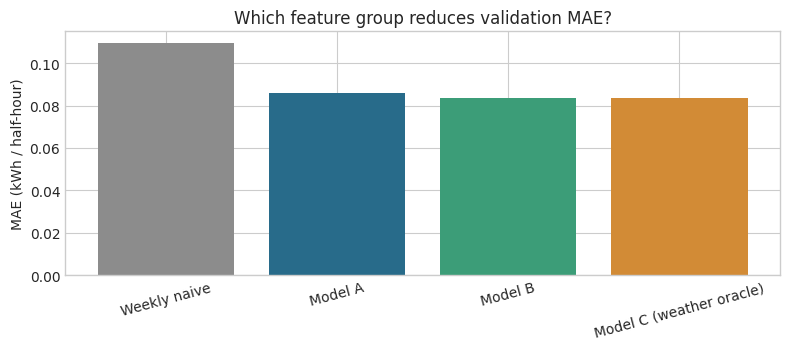

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(comparison['model'], comparison['mae_kwh'], color=['#8c8c8c', '#286b8a', '#3c9d78', '#d28b36'])
ax.set(title='Which feature group reduces validation MAE?', ylabel='MAE (kWh / half-hour)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(FIGURES / 'forecasting_02_model_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

History reduces MAE by 21.5% against weekly naive. Calendar adds a 2.8% gain over Model A.

The weather oracle adds only 0.2% over Model B. This small gain does not justify unavailable future observations.


## 7. Small manual tuning

Model B is the best realistic setup. Test only four small parameter choices.

In [11]:
selected_features = history_features + calendar_features
tuning_options = [
    {'name': 'small trees', 'n_estimators': 350, 'learning_rate': .05, 'num_leaves': 15, 'min_child_samples': 100},
    {'name': 'default size', 'n_estimators': 400, 'learning_rate': .05, 'num_leaves': 31, 'min_child_samples': 50},
    {'name': 'slower learning', 'n_estimators': 700, 'learning_rate': .03, 'num_leaves': 31, 'min_child_samples': 80},
    {'name': 'larger trees', 'n_estimators': 500, 'learning_rate': .05, 'num_leaves': 63, 'min_child_samples': 100},
]

tuning_rows = []
tuned_models = {}
for option in tuning_options:
    params = base_params.copy()
    params.update({key: value for key, value in option.items() if key != 'name'})
    model = LGBMRegressor(**params)
    model.fit(training[selected_features], training['energy_kwh'])
    prediction = np.maximum(model.predict(validation_common[selected_features]), 0)
    error = prediction - validation_common['energy_kwh'].to_numpy()
    tuning_rows.append({'setting': option['name'], 'mae_kwh': np.abs(error).mean(),
                        'rmse_kwh': np.sqrt(np.mean(error ** 2))})
    tuned_models[option['name']] = model

tuning = pd.DataFrame(tuning_rows).sort_values('mae_kwh').reset_index(drop=True)
display(tuning)
best_name = tuning.loc[0, 'setting']
best_model = tuned_models[best_name]
print('Selected setting:', best_name)

,setting,mae_kwh,rmse_kwh
0,larger trees,0.0834,0.1718
1,slower learning,0.0835,0.1719
2,default size,0.0835,0.1719
3,small trees,0.0838,0.1722


Selected setting: larger trees


Larger trees give the best validation MAE, but the tuning gain is small. The search stays limited.

## 8. Validation error analysis

Check households, times and large errors before the final test.

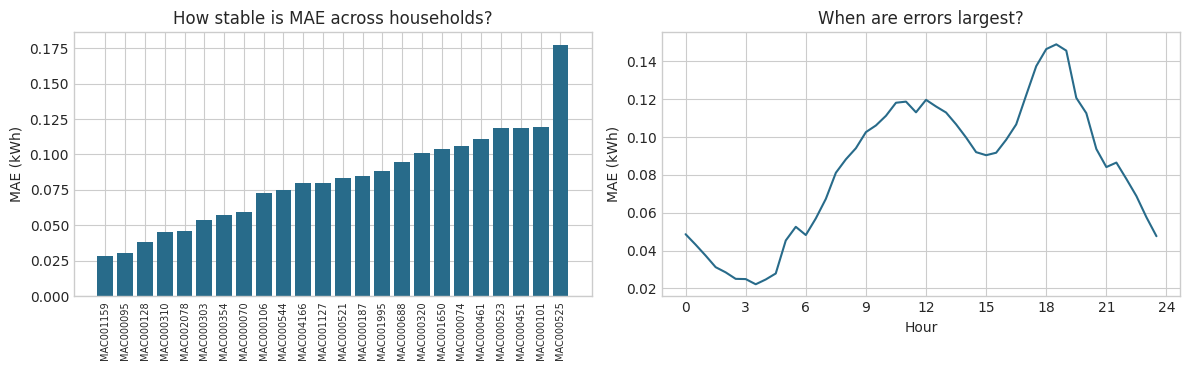

In [12]:
validation_predictions = validation_common.copy()
validation_predictions['predicted_kwh'] = np.maximum(
    best_model.predict(validation_predictions[selected_features]), 0
)
validation_predictions['residual'] = (
    validation_predictions['energy_kwh'] - validation_predictions['predicted_kwh']
)
validation_predictions['absolute_error'] = validation_predictions['residual'].abs()

households = pd.read_csv(PROCESSED / 'households.csv').rename(columns={'LCLid': 'household_id'})
analysis = validation_predictions.merge(
    households[['household_id', 'stdorToU', 'Acorn_grouped']],
    on='household_id', how='left', validate='many_to_one'
)

by_household = analysis.groupby('household_id').agg(
    rows=('absolute_error', 'size'), mae_kwh=('absolute_error', 'mean')
).reset_index().sort_values('mae_kwh')
by_slot = analysis.groupby('slot')['absolute_error'].mean()
by_day = analysis.assign(day=analysis['timestamp'].dt.floor('D')).groupby('day')['absolute_error'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].bar(by_household['household_id'], by_household['mae_kwh'], color='#286b8a')
axes[0].set(title='How stable is MAE across households?', ylabel='MAE (kWh)', xlabel='')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].plot(by_slot.index / 2, by_slot.values, color='#286b8a')
axes[1].set(title='When are errors largest?', xlabel='Hour', ylabel='MAE (kWh)', xticks=range(0, 25, 3))
plt.tight_layout()
plt.savefig(FIGURES / 'forecasting_03_household_slot_errors.png', dpi=140, bbox_inches='tight')
plt.show()

,mean,count
weekend,,
Weekday,0.0805,49497
Weekend,0.0910,19188


,mean,count
stdorToU,,
Std,0.0703,33594
ToU,0.0959,35091


,mean,count
Acorn_grouped,,
Adversity,0.0678,23418
Affluent,0.0942,21857
Comfortable,0.0889,23410


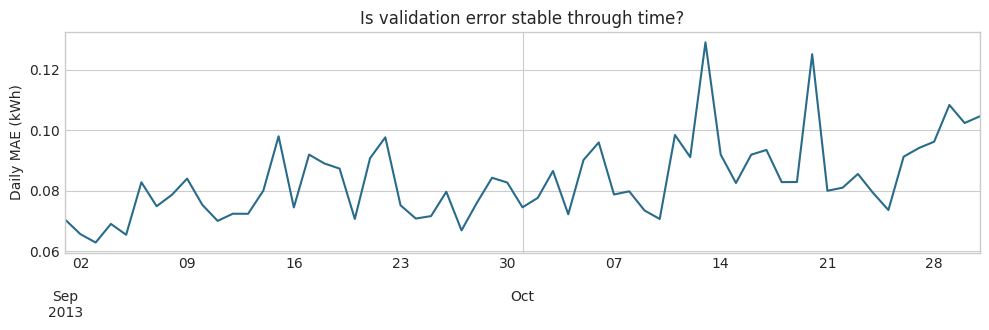

In [13]:
by_weekend = analysis.groupby('weekend')['absolute_error'].agg(['mean', 'count'])
by_tariff = analysis.groupby('stdorToU')['absolute_error'].agg(['mean', 'count'])
by_acorn = analysis.groupby('Acorn_grouped')['absolute_error'].agg(['mean', 'count'])
display(by_weekend.rename(index={0: 'Weekday', 1: 'Weekend'}))
display(by_tariff)
display(by_acorn)

fig, ax = plt.subplots(figsize=(10, 3.4))
by_day.plot(ax=ax, color='#286b8a')
ax.set(title='Is validation error stable through time?', xlabel='', ylabel='Daily MAE (kWh)')
plt.tight_layout()
plt.savefig(FIGURES / 'forecasting_04_error_through_time.png', dpi=140, bbox_inches='tight')
plt.show()

Errors are smallest overnight and largest near the evening peak. Weekend MAE is higher.

Household results vary strongly. Group differences are descriptive because the sample is small and balanced by design.

In [14]:
largest_errors = analysis.nlargest(10, 'absolute_error')[
    ['household_id', 'timestamp', 'energy_kwh', 'predicted_kwh', 'residual', 'absolute_error']
]
display(largest_errors)

,household_id,timestamp,energy_kwh,predicted_kwh,residual,absolute_error
27729,MAC000320,2013-10-31 17:00:00,2.4370,0.0634,2.3736,2.3736
50567,MAC000688,2013-10-20 10:30:00,2.2800,0.1015,2.1785,2.1785
43045,MAC000525,2013-09-15 16:30:00,2.4210,0.2584,2.1626,2.1626
50413,MAC000688,2013-10-17 05:30:00,2.2180,0.0990,2.1190,2.1190
35156,MAC000461,2013-10-03 17:30:00,2.5370,0.4731,2.0639,2.0639
25618,MAC000320,2013-09-17 17:30:00,2.1890,0.1727,2.0163,2.0163
35059,MAC000461,2013-10-01 17:00:00,2.3890,0.3871,2.0019,2.0019
35626,MAC000461,2013-10-13 12:30:00,2.4720,0.4946,1.9774,1.9774
26965,MAC000320,2013-10-15 19:00:00,2.1980,0.2405,1.9575,1.9575
33611,MAC000461,2013-09-01 13:00:00,2.4440,0.5320,1.9120,1.9120


The largest errors are sudden consumption peaks that the model predicts too low. These residuals may help the next anomaly study, but they are not anomaly labels.

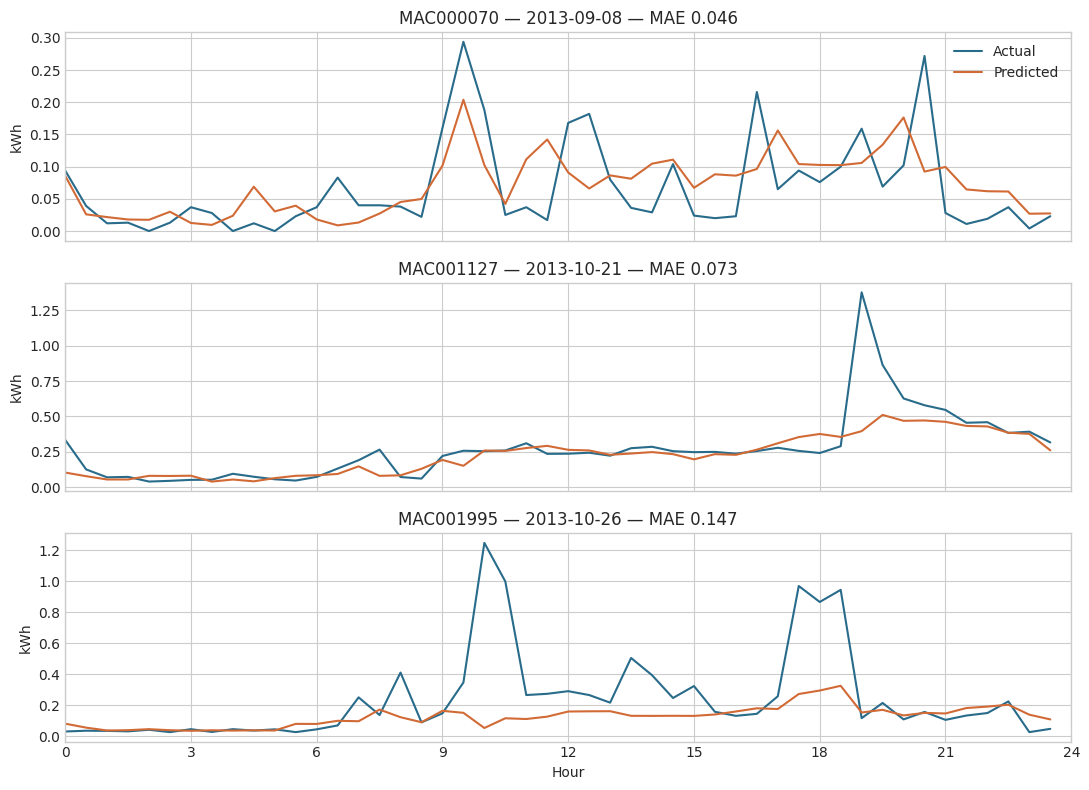

In [15]:
profile_errors = analysis.assign(day=analysis['timestamp'].dt.floor('D')).groupby(
    ['household_id', 'day']
).agg(mae_kwh=('absolute_error', 'mean'), slots=('absolute_error', 'size')).reset_index()
profile_errors = profile_errors.loc[profile_errors['slots'] == 48].sort_values('mae_kwh')

positions = [int(.25 * (len(profile_errors) - 1)), int(.50 * (len(profile_errors) - 1)), int(.90 * (len(profile_errors) - 1))]
examples = profile_errors.iloc[positions]
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, (_, example) in zip(axes, examples.iterrows()):
    profile = analysis.loc[
        (analysis['household_id'] == example['household_id'])
        & (analysis['timestamp'].dt.floor('D') == example['day'])
    ]
    hours = profile['timestamp'].dt.hour + profile['timestamp'].dt.minute / 60
    ax.plot(hours, profile['energy_kwh'], label='Actual', color='#286b8a')
    ax.plot(hours, profile['predicted_kwh'], label='Predicted', color='#d26a36')
    ax.set_title(f"{example['household_id']} — {example['day'].date()} — MAE {example['mae_kwh']:.3f}")
    ax.set_ylabel('kWh')
    ax.set_xlim(0, 23.5)
    ax.set_xticks(range(0, 25, 3))
axes[0].legend()
axes[-1].set_xlabel('Hour')
plt.tight_layout()
plt.savefig(FIGURES / 'forecasting_05_example_profiles.png', dpi=140, bbox_inches='tight')
plt.show()

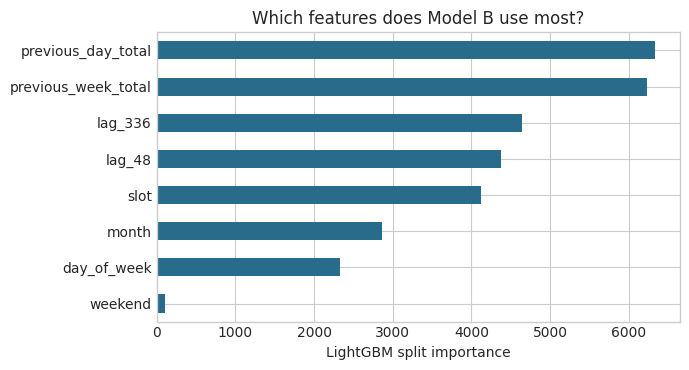

In [16]:
importance = pd.Series(
    best_model.feature_importances_, index=selected_features, name='importance'
).sort_values()
fig, ax = plt.subplots(figsize=(7, 3.8))
importance.plot.barh(ax=ax, color='#286b8a')
ax.set(title='Which features does Model B use most?', xlabel='LightGBM split importance')
plt.tight_layout()
plt.savefig(FIGURES / 'forecasting_06_feature_importance.png', dpi=140, bbox_inches='tight')
plt.show()

## 9. Final model and test

Select tuned Model B. It is realistic and simpler than the weather oracle. Refit it on training and validation, then evaluate the untouched test once.

In [17]:
best_option = next(option for option in tuning_options if option['name'] == best_name)
final_params = base_params.copy()
final_params.update({key: value for key, value in best_option.items() if key != 'name'})

final_training = features.loc[
    features['split'].isin(['train', 'validation']) & features['energy_kwh'].notna()
].copy()
final_model = LGBMRegressor(**final_params)
final_model.fit(final_training[selected_features], final_training['energy_kwh'])

test = features.loc[features['split'] == 'test'].copy()
test_common = test.loc[test['energy_kwh'].notna() & test['lag_336'].notna()].copy()
test_common['predicted_kwh'] = np.maximum(final_model.predict(test_common[selected_features]), 0)
test_common['residual'] = test_common['energy_kwh'] - test_common['predicted_kwh']
test_common['absolute_error'] = test_common['residual'].abs()

test_model_mae = test_common['absolute_error'].mean()
test_model_rmse = np.sqrt(np.mean(test_common['residual'] ** 2))
weekly_test_error = test_common['lag_336'] - test_common['energy_kwh']
weekly_test_mae = weekly_test_error.abs().mean()
weekly_test_rmse = np.sqrt(np.mean(weekly_test_error ** 2))
test_gain = 100 * (weekly_test_mae - test_model_mae) / weekly_test_mae

test_results = pd.DataFrame([
    {'model': 'Weekly naive', 'mae_kwh': weekly_test_mae, 'rmse_kwh': weekly_test_rmse},
    {'model': 'Selected Model B', 'mae_kwh': test_model_mae, 'rmse_kwh': test_model_rmse},
])
display(test_results)
print(f'MAE gain over weekly naive: {test_gain:.1f}%')

,model,mae_kwh,rmse_kwh
0,Weekly naive,0.1535,0.2998
1,Selected Model B,0.1244,0.2568


MAE gain over weekly naive: 18.9%


Test MAE is 0.12441 kWh. This is 18.9% better than weekly naive.

Test error is higher than validation error, which shows a harder winter period. The test result was not used for tuning.


## 10. Save artifacts

Save the final model and holdout residuals for the next project step.

In [18]:
validation_saved = validation_predictions.assign(split='validation')
test_saved = test_common.assign(split='test')
prediction_columns = [
    'household_id', 'timestamp', 'forecast_origin', 'split', 'energy_kwh',
    'predicted_kwh', 'residual', 'absolute_error'
]
predictions = pd.concat([validation_saved, test_saved], ignore_index=True)
predictions[prediction_columns].to_parquet(
    PROCESSED / 'forecasting_predictions.parquet', index=False
)
joblib.dump(final_model, MODELS / 'forecasting_model.joblib')

metadata = {
    'model_family': 'LightGBM LGBMRegressor',
    'features': selected_features,
    'parameters': {key: final_params[key] for key in ['n_estimators', 'learning_rate', 'num_leaves', 'min_child_samples']},
    'final_training_period': '2012-09-01 to 2013-10-31',
    'weather_oracle_is_operational': False,
}
(MODELS / 'forecasting_model_metadata.json').write_text(json.dumps(metadata, indent=2))
print('Saved model and predictions.')

Saved model and predictions.


## Next step: residual analysis

The saved residuals show where the realistic forecast fails. They can support anomaly detection next, without treating every large error as an anomaly.